📌 Célula 1 – Introdução

# Detecção de Fraudes em Cartões de Crédito

Este notebook segue o desafio da DIO para aplicar técnicas de **Machine Learning** em dados de transações de cartão de crédito.

Etapas:
1. Importação de bibliotecas
2. Carregamento e exploração dos dados
3. Feature Engineering
4. Modelos básicos (Logistic Regression)
5. Modelos com balanceamento (Random Forest)
6. Pipeline com scaler
7. Ajuste de threshold
8. Modelo avançado (XGBoost)
9. Importância das variáveis
10. Ajuste de hiperparâmetros


📌 Célula 2 – Instalação de dependências + Importação de bibliotecas

In [1]:
# Instala dependências caso não estejam no ambiente
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost", "scikit-learn", "pandas", "numpy", "matplotlib", "shap", "-q"])
print("Dependencias OK")


Dependencias OK


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_curve, roc_auc_score, precision_recall_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV


📌 Célula 3 – Carregar os dados

In [3]:
import os
import urllib.request
import pandas as pd  # garante que pd esteja disponível mesmo se esta célula rodar isolada

URL = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
LOCAL_PATH = "creditcard.csv"

def download_com_progresso(url, destino):
    """Faz download com barra de progresso no terminal."""
    def reporthook(count, block_size, total_size):
        baixado = count * block_size
        pct = min(baixado / total_size * 100, 100) if total_size > 0 else 0
        mb = baixado / 1_048_576
        print(f"\rBaixando... {pct:.1f}% ({mb:.1f} MB)", end="", flush=True)
    urllib.request.urlretrieve(url, destino, reporthook)
    print("\nDownload concluido!")

if os.path.exists(LOCAL_PATH):
    print(f"Arquivo local encontrado: {LOCAL_PATH} — pulando download.")
else:
    print(f"Baixando dataset (~143MB)...")
    download_com_progresso(URL, LOCAL_PATH)

df = pd.read_csv(LOCAL_PATH)
print(f"Shape: {df.shape}")
df.head()


Arquivo local encontrado: creditcard.csv — pulando download.
Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


📌 Célula 4 – Exploração inicial

In [4]:
# Verificamos o desbalanceamento da variável alvo (Class).
# Classe 0 = transação normal, Classe 1 = fraude.
print(df["Class"].value_counts())
print("\nProporção:")
print(df["Class"].value_counts(normalize=True))

# Calculamos o ratio real para uso no XGBoost (scale_pos_weight)
ratio_neg_pos = int(df["Class"].value_counts()[0] / df["Class"].value_counts()[1])
print(f"\nRatio negativo/positivo: {ratio_neg_pos}")


Class
0    284315
1       492
Name: count, dtype: int64

Proporção:
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

Ratio negativo/positivo: 577


📌 Célula 5 – Feature Engineering

In [ ]:
# Criamos Amount_log: logaritmo do valor da transação.

df["Amount_log"] = np.log1p(df["Amount"])

print("Feature Amount_log criada.")
print(df[["Amount", "Amount_log"]].describe())


Feature Amount_log criada.
              Amount     Amount_log
count  284807.000000  284807.000000
mean       88.349619       3.152188
std       250.120109       1.656648
min         0.000000       0.000000
25%         5.600000       1.887070
50%        22.000000       3.135494
75%        77.165000       4.358822
max     25691.160000      10.153941


📌 Célula 6 – Separar treino e teste

In [ ]:

X = df.drop(["Class", "Time", "Amount"], axis=1)  # inclui Amount_log
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.3, random_state=42
)

print(f"Treino: {X_train.shape} | Teste: {X_test.shape}")
print(f"Features usadas ({len(X.columns)}): {list(X.columns)}")


Treino: (199364, 29) | Teste: (85443, 29)
Features usadas (29): ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount_log']


📌 Célula 7 – Logistic Regression 

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     85295
           1       0.06      0.88      0.12       148

    accuracy                           0.98     85443
   macro avg       0.53      0.93      0.55     85443
weighted avg       1.00      0.98      0.99     85443



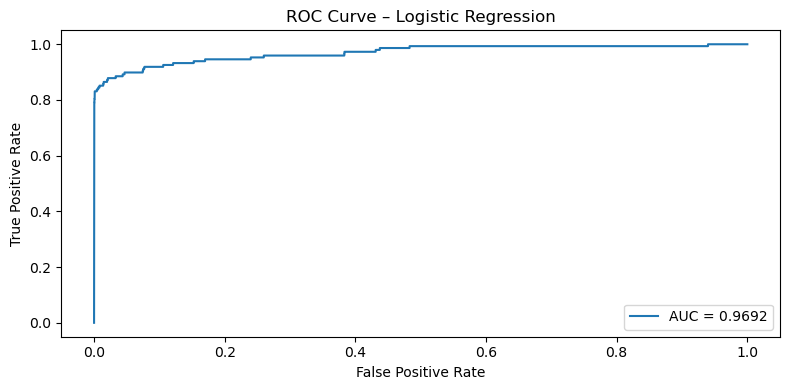

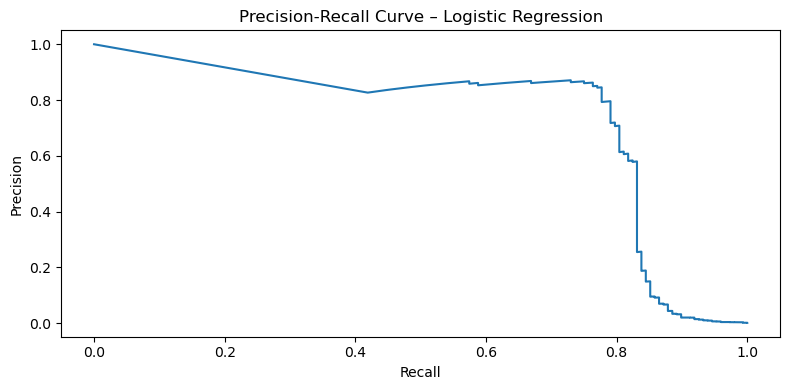

In [ ]:
# Modelo básico de regressão logística com normalização.
scaler_lr = StandardScaler()
X_train_scaled = scaler_lr.fit_transform(X_train)
X_test_scaled  = scaler_lr.transform(X_test)  
model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred))

# Guardamos as probabilidades desta célula com nome específico
y_probs_lr = model.predict_proba(X_test_scaled)[:, 1]

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_probs_lr)
plt.figure(figsize=(8, 4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_probs_lr):.4f}")
plt.title("ROC Curve – Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

# Precision-Recall
precision, recall, _ = precision_recall_curve(y_test, y_probs_lr)
plt.figure(figsize=(8, 4))
plt.plot(recall, precision)
plt.title("Precision-Recall Curve – Logistic Regression")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.tight_layout()
plt.show()


📌 Célula 8 – Random Forest com balanceamento

In [ ]:

rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))


=== Random Forest ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.84      0.77      0.81       148

    accuracy                           1.00     85443
   macro avg       0.92      0.89      0.90     85443
weighted avg       1.00      1.00      1.00     85443



📌 Célula 9 – Pipeline + Ajuste de Threshold

In [ ]:
# Pipeline que aplica StandardScaler antes da Logistic Regression.
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])
pipeline.fit(X_train, y_train)
y_pred_pipe = pipeline.predict(X_test)

print("=== Pipeline Logistic Regression ===")
print(classification_report(y_test, y_pred_pipe))


y_probs_pipe = pipeline.predict_proba(X_test)[:, 1]

# Threshold mais baixo = mais sensível a fraudes (mais recall, menos precision).
threshold = 0.3
y_pred_custom = (y_probs_pipe > threshold).astype(int)
print(f"=== Pipeline com Threshold = {threshold} ===")
print(classification_report(y_test, y_pred_custom))


=== Pipeline Logistic Regression ===
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     85295
           1       0.06      0.88      0.12       148

    accuracy                           0.98     85443
   macro avg       0.53      0.93      0.55     85443
weighted avg       1.00      0.98      0.99     85443

=== Pipeline com Threshold = 0.3 ===
              precision    recall  f1-score   support

           0       1.00      0.95      0.97     85295
           1       0.03      0.90      0.06       148

    accuracy                           0.95     85443
   macro avg       0.52      0.92      0.52     85443
weighted avg       1.00      0.95      0.97     85443



📌 Célula 10 – XGBoost

=== XGBoost ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.89      0.78      0.83       148

    accuracy                           1.00     85443
   macro avg       0.94      0.89      0.92     85443
weighted avg       1.00      1.00      1.00     85443



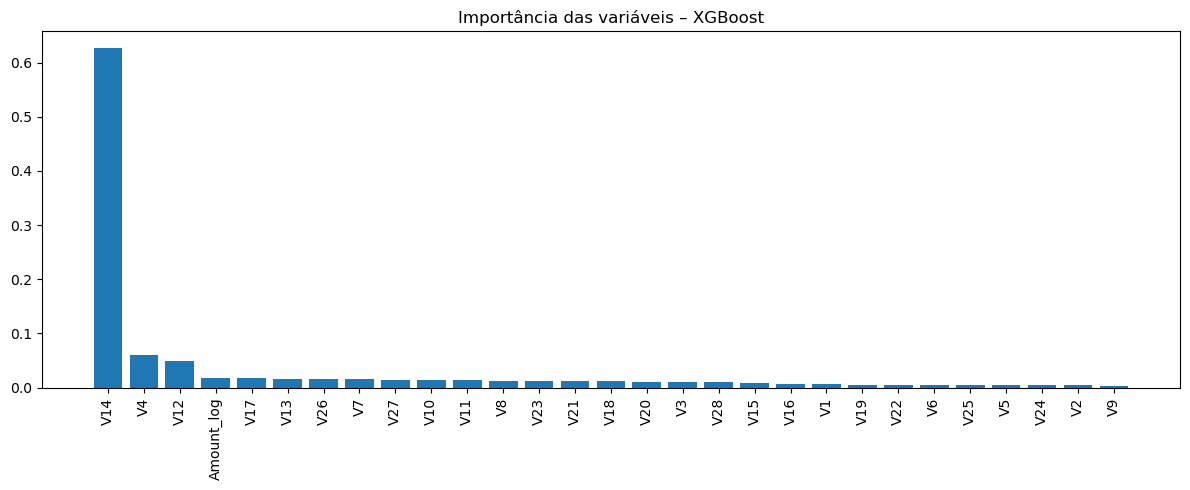

In [ ]:

xgb = XGBClassifier(
    scale_pos_weight=ratio_neg_pos,
    eval_metric="logloss",
    random_state=42
)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb))

# Importância das variáveis com labels
importances = xgb.feature_importances_
feature_names = X_train.columns
sorted_idx = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 5))
plt.bar(range(len(importances)), importances[sorted_idx])
plt.xticks(range(len(importances)), feature_names[sorted_idx], rotation=90)
plt.title("Importância das variáveis – XGBoost")
plt.tight_layout()
plt.show()


📌 Célula 11 – Ajuste de Hiperparâmetros

In [ ]:

param_grid = {
    "max_depth": [3, 5],
    "n_estimators": [50, 100],
    "scale_pos_weight": [ratio_neg_pos]
}
grid = GridSearchCV(
    XGBClassifier(eval_metric="logloss", random_state=42),
    param_grid,
    scoring="recall",
    cv=3,
    n_jobs=-1,
    verbose=1
)
grid.fit(X_train, y_train)
print("Melhores hiperparâmetros:", grid.best_params_)

# Avaliação do melhor modelo encontrado
y_pred_best = grid.best_estimator_.predict(X_test)
print("\n=== Melhor Modelo (GridSearchCV) ===")
print(classification_report(y_test, y_pred_best))


Fitting 3 folds for each of 4 candidates, totalling 12 fits
Melhores hiperparâmetros: {'max_depth': 3, 'n_estimators': 50, 'scale_pos_weight': 577}

=== Melhor Modelo (GridSearchCV) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.34      0.85      0.49       148

    accuracy                           1.00     85443
   macro avg       0.67      0.92      0.74     85443
weighted avg       1.00      1.00      1.00     85443



📌 Célula 12 – Explicabilidade com SHAP 

=== SHAP Bar – importância média das features ===


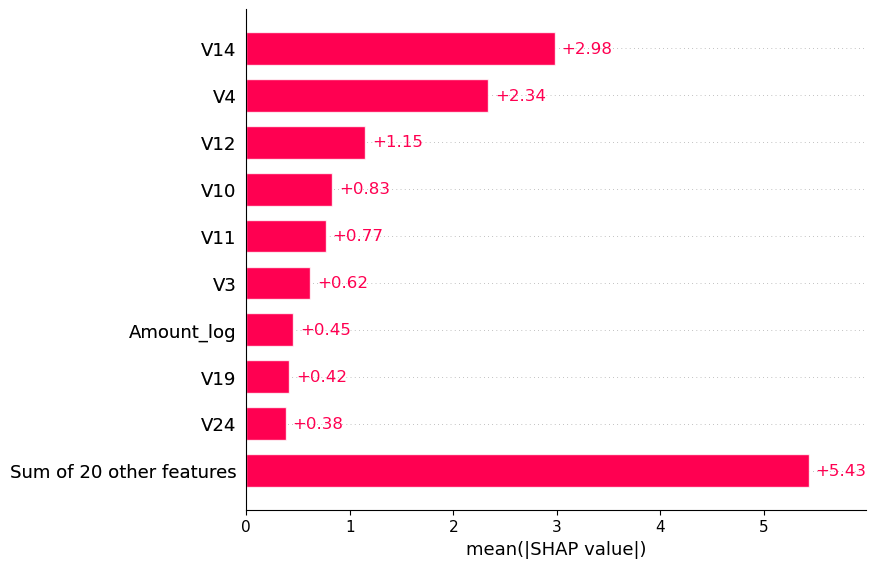

=== SHAP Beeswarm – impacto por amostra ===


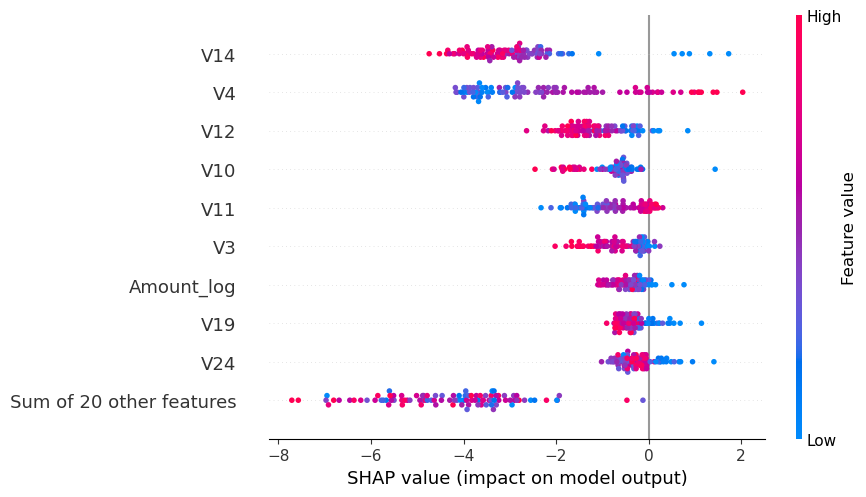

=== SHAP Waterfall – explicação da amostra 0 ===


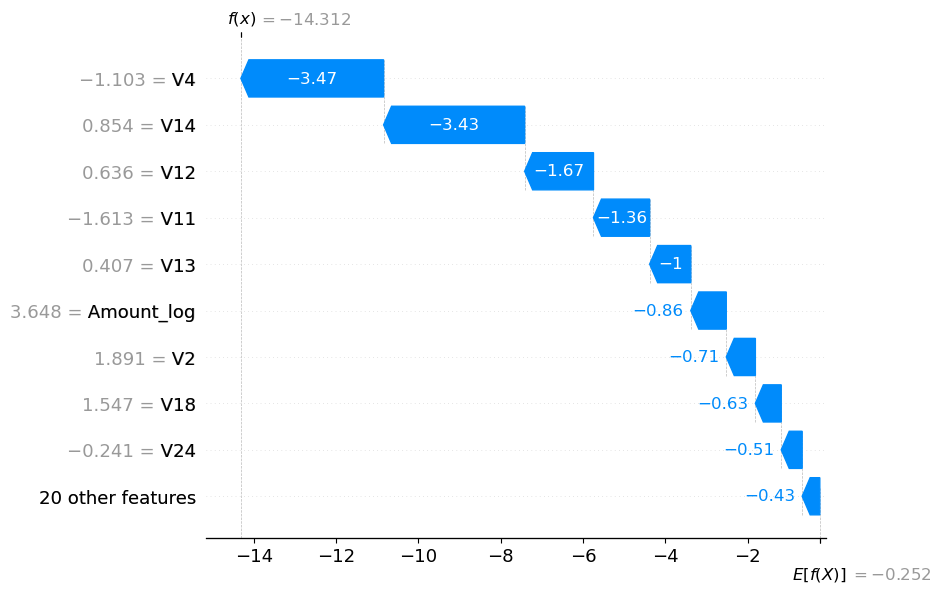

In [12]:
import shap

# TreeExplainer é o mais eficiente para modelos baseados em árvore (XGBoost, RF).
# Usamos X_test[:100] para calcular rápido — 100 amostras já são suficientes.
explainer = shap.Explainer(xgb)
shap_values = explainer(X_test[:100])

# Bar plot: importância média absoluta de cada feature
print('=== SHAP Bar – importância média das features ===')
shap.plots.bar(shap_values)

# Beeswarm: distribuição do impacto por amostra (positivo = puxa para fraude)
print('=== SHAP Beeswarm – impacto por amostra ===')
shap.plots.beeswarm(shap_values)

# Waterfall: explicação individual da primeira transação do conjunto de teste
print('=== SHAP Waterfall – explicação da amostra 0 ===')
shap.plots.waterfall(shap_values[0])
